<a href="https://colab.research.google.com/github/myriosMin/resume-classifier-NLP/blob/main/data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import string
from random import randint
from collections import Counter, defaultdict
import importlib.util
import subprocess
import sys
from tqdm import trange
import chardet
import os
import pdfplumber
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import matthews_corrcoef
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
tfidf_vectorizer = TfidfVectorizer()

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

import nltk
from nltk.corpus import stopwords, words, wordnet

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

nltk.download('punkt_tab')
nltk.download('punkt')

nltk.download('words')
nltk_vocab = set(words.words())

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

from transformers import AdamW, BertConfig, BertForSequenceClassification, BertModel, BertTokenizer
from transformers import BertTokenizer, BertModel
bert_model = BertModel.from_pretrained("bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)
bert_model.eval()

import gensim.downloader
word2vec_model = gensim.downloader.load('glove-wiki-gigaword-50')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/NYP/Year2/NLP/MIN PHYO THURA_dataset.csv"
# Detect the encoding
raw_text = open(csv_path, "rb").read()
encoding = chardet.detect(raw_text)['encoding']
print(f"Deteced encoding format: {encoding}")

# Load the csv as a pandas df
df = pd.read_csv("/content/drive/MyDrive/NYP/Year2/NLP/MIN PHYO THURA_dataset.csv",
                 encoding=encoding)
df.head()

Deteced encoding format: utf-8


,Category,Resume
0,Hadoop,Technical Skill Set: Programming Languages Apa...
1,Mechanical Engineer,SKILLS: â¢ Knowledge of software / computer: ...
2,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...
3,Electrical Engineering,Education Details \r\nJanuary 2012 to January ...
4,Business Analyst,Key Skills - Requirement Gathering - Requireme...


In [ ]:
# Rename columns for accuracy
df.rename(columns={'Category': 'category', 'Resume': 'resume'}, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  962 non-null    object
 1   resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [ ]:
# correct data types


### Add in my resume

In [ ]:
# extract text from PDF
def extract_text(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() + "\n"
    return text

pdf_path = "/content/drive/MyDrive/NYP/Year2/NLP/233523A_MinPhyoThura_CV.pdf"
txt_path = os.path.basename(pdf_path).replace(".pdf", ".txt")

# extract text from PDF
text = extract_text(pdf_path)

# save to .txt file
with open(txt_path, "w", encoding="utf-8") as f:
    f.write(text)

print("Text extraction complete!")

Text extraction complete!


In [ ]:
# see the result of first few lines
lines = text.split("\n")
print("\n".join(lines[:10]))

M
in Phyo Thura
Machine Learning Engineer
+(65)80150905 · myriosmin@gmail.com
linkedIn.com/in/min-phyo-thura/ · myriosmin.com/about
An undergraduate fresher in Computer Science & Neuroscience | MIT Class of 2030
As both an academic achiever and a real-world problem solver, I excel in implementing scaleable high-
impact AI solutions with my innovativeness on top of my strong Mathematical and technical foundations.
Education
Massachusetts Institute of Technology | Cambridge USA June 2023 - Present


In [ ]:
# append it to the end of df
new_row = {'category': 'Min Phyo Thura', 'resume': text}
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df.tail()

,category,resume
958,Sales,IT Skills: MS Office. Photoshop. SQL Server.Ed...
959,Java Developer,Technical Skills (Trained / Project Acquired S...
960,Network Security Engineer,"Technical Expertise: â¢ Cisco ASA, Checkpoint..."
961,DotNet Developer,"Technical Skills CATEGORY SKILLS Language C, C..."
962,Min Phyo Thura,M\nin Phyo Thura\nMachine Learning Engineer\n+...


In [ ]:
# randomly inspect the resume
def check_randomly(id=None):
  index = id
  if index is None:
    index = randint(0, df.shape[0])
  print("Index: ", index)
  return df['resume'].iloc[index]

check_randomly(854)

Index:  854


"Education Details \r\nJanuary 2015 Bachelor of Engineering EXTC Mumbai, Maharashtra Mumbai University\r\nJanuary 2012 Diploma Industrial Electronics Vashi, MAHARASHTRA, IN Fr. Agnel Polytechnic\r\nETL Developer \r\n\r\nETL Developer\r\nSkill Details \r\ninformatica- Exprience - 36 monthsCompany Details \r\ncompany - Blue Shield of California\r\ndescription - Duration: (Mar 2016 - Sept 2017)\r\n\r\nDescription:\r\nBlue Shield of California (BSC) is health plan provider. The intent of this project is to process feeds coming in and going out of BSC system related to eligibility, enrollment, and claims subject areas. All these feeds comes in different formats and are processed using Informatica 9.6.1, Oracle 11g, Facets 5.0 &Tidal.\r\n\r\nTechnical environment: ETL tool (Informatica power Center 9.6.1), Oracle 11g (SQL, PL-SQL), UNIX, Facets, Tidal, JIRA, Putty.\r\n\r\nRole: ETL Developer\r\nResponsibilities: â\x80¢ Responsible for analyzing the business requirement document â\x80¢ Involv

In [ ]:
# seeing â\x80¢, it seems some resumes are in Latin1 encoding
def latin1_to_utf8(text):
  try:
    text = text.encode('latin1').decode('utf-8')
  except:
    pass
  return text

df['resume'] = df['resume'].apply(latin1_to_utf8)

In [ ]:
check_randomly(854)

Index:  854


"Education Details \r\nJanuary 2015 Bachelor of Engineering EXTC Mumbai, Maharashtra Mumbai University\r\nJanuary 2012 Diploma Industrial Electronics Vashi, MAHARASHTRA, IN Fr. Agnel Polytechnic\r\nETL Developer \r\n\r\nETL Developer\r\nSkill Details \r\ninformatica- Exprience - 36 monthsCompany Details \r\ncompany - Blue Shield of California\r\ndescription - Duration: (Mar 2016 - Sept 2017)\r\n\r\nDescription:\r\nBlue Shield of California (BSC) is health plan provider. The intent of this project is to process feeds coming in and going out of BSC system related to eligibility, enrollment, and claims subject areas. All these feeds comes in different formats and are processed using Informatica 9.6.1, Oracle 11g, Facets 5.0 &Tidal.\r\n\r\nTechnical environment: ETL tool (Informatica power Center 9.6.1), Oracle 11g (SQL, PL-SQL), UNIX, Facets, Tidal, JIRA, Putty.\r\n\r\nRole: ETL Developer\r\nResponsibilities: • Responsible for analyzing the business requirement document • Involved in deve

In [ ]:
# control characters: \r \n
# non-english characters: Ã â ¢
# math operators/ punctuation marks: ± - :

# how about category Column?
df['category'].value_counts()

,count
category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
ETL Developer,40
Sales,40


In [ ]:
# null check
df.isnull().sum()

,0
category,0
resume,0


In [ ]:
# no null; but still make it certain

initial_size = df.shape[0]
def track_data_size(initial_size, operation, prev_drop=0):
  num_dropped = initial_size - df.shape[0] + prev_drop
  print(f"Dropped {num_dropped} records during {operation}.")
  print(f"Percentage dropped: {(num_dropped/initial_size)*100:.2f}%")
  return num_dropped

df.dropna(inplace=True)
null_count = track_data_size(initial_size, "NULL drop")
assert df.isnull().sum().sum() == 0

Dropped 0 records during NULL drop.
Percentage dropped: 0.00%


In [ ]:
# duplicate check
df.duplicated().sum()

744

In [ ]:
# suspicious number of duplicates; inspect a bit more before dropping
df[df.duplicated(keep=False)]

,category,resume
1,Mechanical Engineer,SKILLS: ➢ Knowledge of software / computer: Au...
2,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...
3,Electrical Engineering,Education Details \r\nJanuary 2012 to January ...
4,Business Analyst,Key Skills - Requirement Gathering - Requireme...
5,DevOps Engineer,Skills VISA B1-VISA (USA) Onsite Visits to Swe...
...,...,...
956,DevOps Engineer,Skills VISA B1-VISA (USA) Onsite Visits to Swe...
957,Sales,SKILLS 1. MS-Office 2. Good Communication skil...
958,Sales,IT Skills: MS Office. Photoshop. SQL Server.Ed...
959,Java Developer,Technical Skills (Trained / Project Acquired S...


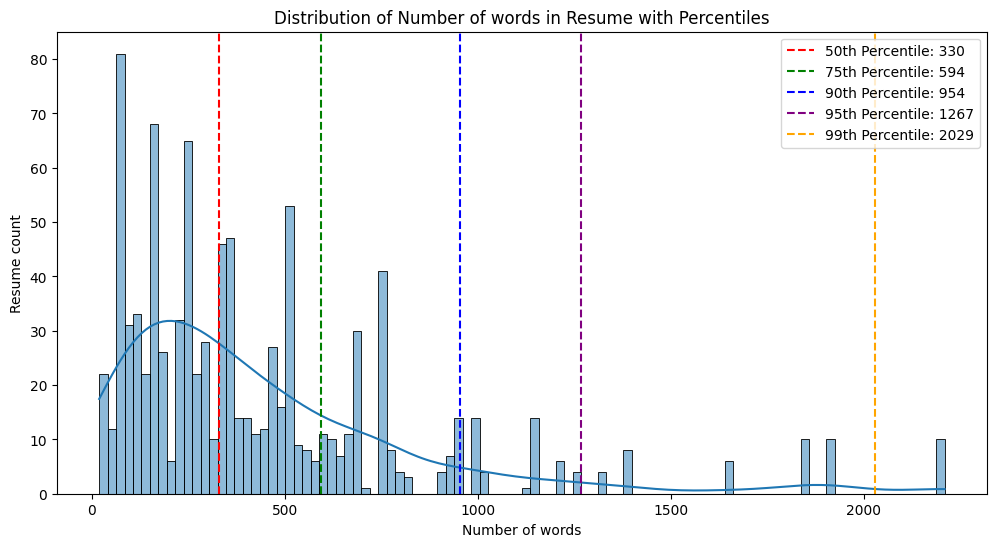

In [ ]:
# Visualize word count in each resume to detect anomalies and determine token length for BERT
def plot_distribution(df, col, drop=True):
  try:
  # Count the number of words in each resume
    df['num_words'] = df[col].apply(lambda x: len(str(x).split())) # strings
    var = "words"
  except:
    df['num_words'] = df[col].apply(lambda x: len(x)) # tokens
    var = "tokens"

  # Calculate percentiles for token length selection
  percentiles = np.percentile(df['num_words'], [50, 75, 90, 95, 99])

  # Plot the histogram with percentiles
  plt.figure(figsize=(12, 6))
  sns.histplot(df, x='num_words', bins=100, kde=True)

  # Add vertical percentile lines
  plt.axvline(percentiles[0], color='r', linestyle='--', label=f'50th Percentile: {int(percentiles[0])}')
  plt.axvline(percentiles[1], color='g', linestyle='--', label=f'75th Percentile: {int(percentiles[1])}')
  plt.axvline(percentiles[2], color='b', linestyle='--', label=f'90th Percentile: {int(percentiles[2])}')
  plt.axvline(percentiles[3], color='purple', linestyle='--', label=f'95th Percentile: {int(percentiles[3])}')
  plt.axvline(percentiles[4], color='orange', linestyle='--', label=f'99th Percentile: {int(percentiles[4])}')

  # Labels and title
  plt.legend()
  plt.title(f'Distribution of Number of {var} in Resume with Percentiles')
  plt.xlabel(f'Number of {var}')
  plt.ylabel(f'Resume count')
  plt.show()

  # Drop word counts if uncessary
  if drop:
    df.drop('num_words', axis=1, inplace=True)

plot_distribution(df, 'resume', drop=False)

In [ ]:
# some resumes are quite long
# even using 512 max tokens in BERT Classifier later will only fully cover ~60% of the resume.
# i.e., only the first 512 tokens (~384 words) from the rest 40% of the resumes will be used by BERT for classification, losing information from 513rd token onwards.
# will be dealt later

# check the most extreme ones
df.sort_values(by='num_words', ascending=False).drop_duplicates().head()

,category,resume,num_words
732,Operations Manager,Education Details \r\nAugust 2000 B.E Electron...,2209
286,Operations Manager,IT SKILLS • Well versed with MS Office and Int...,1919
580,Operations Manager,Education Details \r\n BCA Vinayaka Missions...,1849
726,Operations Manager,Education Details \r\n BCA Vinayaka Missions...,1848
650,Business Analyst,IT Skills: Area Exposure Modeling Tool: Bizagi...,1644


In [ ]:
check_randomly(732)

Index:  732


"Education Details \r\nAugust 2000 B.E Electronics Pune, Maharashtra Pune University\r\nOperations Manager \r\n\r\nOperations Manager - Delta Controls, Dubai FZCO\r\nSkill Details \r\nCompany Details \r\ncompany - Delta Controls, Dubai FZCO\r\ndescription - Heading Pune Branch [M/s Deltannex Integrators Pvt. Ltd.]                        From Aug '17 till date\r\nDesignation - Operations Manager [1st Employee] \r\n1. Reporting to the GM-Operations 2. Review of SOW, RFQ, Assist the proposal Team on the Engineering man hours, Project Schedule, Organization\r\nChart and Meeting the client for pre-sales support 3. Review of SOW, RFQ, Client's Purchase Order or contract terms & conditions 4. Project Execution Plans after through discussion with client & consultants 5. Kick of meeting & Ad-hoc meetings with client 6. Project evaluation in terms of outlays & profits 7. Ensuring an appropriate project management framework 8. Management of all contractual and commercial issues related to the pro

In [ ]:
check_randomly(650)

Index:  650


"IT Skills: Area Exposure Modeling Tool: Bizagi, MS Visio Prototyping Tool: Indigo Studio. Documentation: MS Office (MS Word, MS Excel, MS Power Point) Testing Proficiency: Smoke, Sanity, Integration, Functional, Acceptance and UI Methodology implemented: Waterfall, Agile (Scrum) Database: SQL Testing Tool: HPQC Business Exposure Education Details \r\n Bachelor Of Computer Engineering Computer Engineering Mumbai, Maharashtra Thadomal Shahani Engineering college\r\n Diploma Computer Engineering Ulhasnagar, Maharashtra Institute of Technology\r\n Secondary School Certificate  Ulhasnagar, Maharashtra New English High School\r\nSenior Business Analyst - RPA \r\n\r\nSenior Business Analyst - RPA - Hexaware Technologies\r\nSkill Details \r\nDOCUMENTATION- Exprience - 47 months\r\nTESTING- Exprience - 29 months\r\nINTEGRATION- Exprience - 25 months\r\nINTEGRATOR- Exprience - 25 months\r\nPROTOTYPE- Exprience - 13 monthsCompany Details \r\ncompany - Hexaware Technologies\r\ndescription - Worki

In [ ]:
# they are genuine resumes despite the length and duplicates

# check the shortest ones
df.sort_values(by='num_words', ascending=True).drop_duplicates().head()

,category,resume,num_words
121,HR,Education Details \r\n BBA lovely profession...,19
395,HR,Education Details \r\n MBA ACN College of en...,20
258,Advocate,Education Details \r\n LLB. Dibrugarh Univer...,24
582,HR,Education Details \r\n BA mumbai University\...,24
619,HR,Education Details \r\nJune 2012 to May 2015 B....,26


In [ ]:
check_randomly(121)

Index:  121


'Education Details \r\n BBA   lovely professional university\r\nHR \r\n\r\n\r\nSkill Details \r\nCommunication- Exprience - 6 monthsCompany Details \r\ncompany - \r\ndescription - '

In [ ]:
check_randomly(619)

Index:  619


'Education Details \r\nJune 2012 to May 2015 B.A Economics Chennai, Tamil Nadu Sdnbvc\r\nHr \r\n\r\n\r\nSkill Details \r\nCompany Details \r\ncompany - Anything IT Solution\r\ndescription - Hr'

In [ ]:
# these also seem fine except the resumes are incomplete, and there are duplicates
# they should be regarded as 'bad' resumes instead of dropping them for being incomplete

# the duplicates are quite problematic as they are 'actual' duplicates
# they will be deleted, assuming these duplicates could be a result of
# 1. job applicants spamming the company's job application portal by using bots to submit the their same resume multiple times
# 2. another AI enginner colleague accidently creating duplicates due to an error in code
# or, maybe coincidentally, some people with same qualifications are applying for the same role

# not deleting these may affect the project by
# 1. introducing bias in later NLP models
# 2. wasting unnecessary computing resources
# 3. no point in analyzing the same thing as we are not interested in how common a resume is for a certain job role

# drop them
df.drop_duplicates(inplace=True)
dul_count = track_data_size(initial_size, 'DROP DUPLICATES', null_count)
assert df.duplicated().sum() == 0

# drop num_words
df.drop('num_words', axis=1, inplace=True)

Dropped 744 records during DROP DUPLICATES.
Percentage dropped: 77.26%


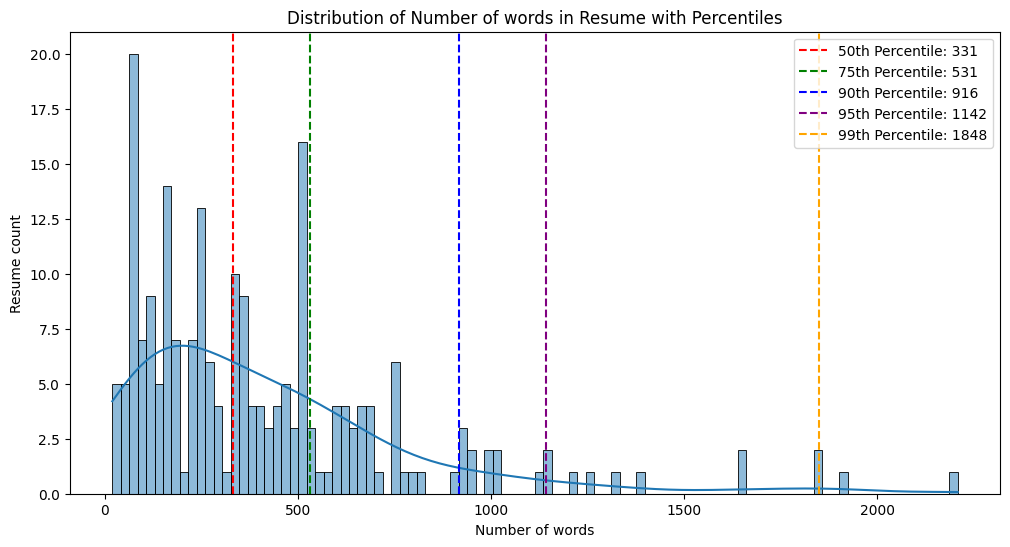

In [ ]:
# way to suspicious to drop 77% of the data .....

# plot distribution after dropna and drop_duplicates
plot_distribution(df, 'resume')

In [ ]:
# still long tokens; dealt later

# Text Preprocessing

In [ ]:
def clean_resume(text):
    # Step 1: Replace special symbols with their meanings
    text = re.sub(r'&|<|>|/|\\', lambda m: {'&': ' and ',
                                            '<': ' less than ',
                                            '>': ' greater than ',
                                            '/': ' or ',
                                            '\\': ' or '}[m.group()], text)

    # Step 2: Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Step 3: Remove control characters (newlines, tabs, etc.)
    text = re.sub(r'[\r\n\t]', ' ', text)

    # Step 4: Remove random symbols (excluding word characters and spaces)
    text = re.sub(r'[-±:`~!^*()_=]', ' ', text)

    # Step 5: Deal with special 'words' like C++ C#
    valid_cpp_variations = [
        "C++", "c++", "C ++", "c ++", "C++-", "c++-", "C ++-", "c ++-",
        "C++,", "c++,", "C ++,", "c ++,", "C++.", "c++.", "C ++.", "c ++.",
        "C#", "c#", "C #", "c #", "C#-", "c#-", "C #-", "c #-",
        "C#,", "c#,", "C #,", "c #,", "C#.", "c#.", "C #.", "c #."
    ]

    # Temporarily replace valid "C++" variations with placeholders
    for variant in valid_cpp_variations:
        text = text.replace(variant, "CXXPLUSXX")

    # Normalize "C#" variations before further processing
    text = re.sub(r'\b[Cc]\s*#\b', 'C#', text)  # Normalize variations like "C #", "c#"

    # Temporarily replace "C#" to protect it
    text = text.replace("C#", "CXXHASHXX")

    # Step 6: Remove standalone "++" and "#" (not part of protected "C++" or "C#")
    text = re.sub(r'(?<!C)(?<!c)\+\+', '', text)
    text = re.sub(r'(?<!C)(?<!c)#', '', text)

    # Step 7: Remove all other punctuation except words and spaces
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 8: Restore "C++" and "C#" from placeholders
    text = text.replace("CXXPLUSXX", "C++")
    text = text.replace("CXXHASHXX", "C#")

    return text

# Apply the function to the dataframe
df['resume'] = df['resume'].apply(clean_resume)

In [ ]:
check_randomly(25)

Index:  25


'Technical Skills Programming Languages  C  C++  Java   Net   J2EE  HTML5  CSS  MapReduce Scripting Languages  Javascript  Python Databases  Oracle  PL SQL   MY SQL  IBM DB2 Tools IBM Rational Rose  R  Weka Operating Systems  Windows XP  Vista  UNIX  Windows 7  Red Hat 7Education Details   January 2015 B E  Pimpri Chinchwad  MAHARASHTRA  IN Pimpri Chinchwad College of Engineering  January 2012 Diploma MSBTE  Dnyanganaga Polytechnic   S S C   New English School Takali  Hadoop or Big Data Developer     Hadoop or Big Data Developer   British Telecom  Skill Details   APACHE HADOOP MAPREDUCE  Exprience   37 months  MapReduce  Exprience   37 months  MAPREDUCE  Exprience   37 months  JAVA  Exprience   32 months   NET  Exprience   6 monthsCompany Details   company   British Telecom  description   Project  British Telecom project  UK   Responsibilities     Working on HDFS  MapReduce  Hive  Spark  Scala  Sqoop  Kerberos etc  technologies    Implemented various data mining algorithms on Spark lik

In [ ]:
# saw another interesting issue: random characters like 'f5qj2rh7b0'
# deletening these 'non-meaningful' words would be quite tricky to deal with unless we have a comprehensive vocabulary corpus that includes modern words and acronyms like blockchain, erp, sap...

# no choice but to do it manually

# Function to extract OOV words from text
def find_oov_words(text):
    tokens = re.findall(r'\b[a-zA-Z0-9]+\b', text)  # Extract words efficiently
    lemmatized_tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens]
    return [word.lower() for word in tokens if word.lower() not in nltk_vocab]

# Apply function to all resumes and get a single list of OOV words
all_oov_words = set()  # Use a set to ensure uniqueness
df["resume"].apply(lambda text: all_oov_words.update(find_oov_words(text)))

# Convert set to sorted list
unique_oov_words = sorted(all_oov_words)

# Inspect result
columns = 6
oov_count = len(unique_oov_words)
remainder = oov_count % columns
if remainder != 0:
    for i in range(columns - remainder):
      unique_oov_words += ['']
oov_array = np.array(unique_oov_words)
oov_array = np.reshape(oov_array, (-1, columns))  # Reshape into multiple columns

print(pd.DataFrame(oov_array).to_string(index=False, header=False))

                  0                    000                            01                   017                     02                     03
                 04                   04th                            05          050education                   06th                     07
        07education                     08                   09876971076            0education                      1                     10
                100                    101                           104                   108                    109                    10g
   10magicalfingers                     11                           110                  110v                  11171                    115
                118                   1180                           11g          11geducation                  11gr2                   11kv
                 12                    120                          1200                   125                    12c                    12d
             

In [ ]:
# quite subkective; so only those that are super obiviously random will be deleted.
# a lot of indian words and acronyms are detected.
imp_words = ["0", "000", "aofpt5052c", "kw", "yyyy", "mm", "dd", "F5qJ2rH7B0"]

for word in imp_words:
    try:
        unique_oov_words.remove(word)
    except ValueError:
        pass

# remove imp_words
df['resume'] = df['resume'].apply(lambda x: ' '.join([word for word in x.split() if word not in imp_words]))

# duplicates might appear again after these preprocessing techniques
df.duplicated().sum()

35

In [ ]:
# as expected; drop them
df.drop_duplicates(inplace=True)
assert df.duplicated().sum() == 0
assert df.isnull().sum().sum() == 0

### Tokenization

In [ ]:
"""Tokenization"""
# character tokenization is way too primitive and uneffective as it's difficult to inference any meaning from characters alone
# either word or subword tokenization
# word tokenization is used for its simple interpretability

df['tokens'] = df['resume'].apply(lambda x: nltk.word_tokenize(x))

df.head()

,category,resume,tokens
0,Hadoop,Technical Skill Set Programming Languages Apac...,"[Technical, Skill, Set, Programming, Languages..."
1,Mechanical Engineer,SKILLS Knowledge of software or computer Auto ...,"[SKILLS, Knowledge, of, software, or, computer..."
2,Testing,Skill Set OS Windows XP or 7 or 8 or 8 1 or 10...,"[Skill, Set, OS, Windows, XP, or, 7, or, 8, or..."
3,Electrical Engineering,Education Details January 2012 to January 2013...,"[Education, Details, January, 2012, to, Januar..."
4,Business Analyst,Key Skills Requirement Gathering Requirement A...,"[Key, Skills, Requirement, Gathering, Requirem..."


In [ ]:
"""Lemmatization"""

# Extract uppercase words from resume (potential acronyms)
def extract_acronyms(text):
    return set(re.findall(r'\b[A-Z]{2,}\b', text))  # Finds words with ALL CAPS (2+ letters)

# Get WordNet POS tag
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, None)  # Only return POS tag if found

# Lemmatize words while preserving acronyms
def lemmatize_words(tokens, acronyms):
    lemmatized_tokens = []
    for word in tokens:
        if word.upper() in acronyms:  # If word is in extracted acronyms, keep it
            lemmatized_tokens.append(word.upper())  # Preserve original uppercase
        else:
            pos = get_wordnet_pos(word)  # Get POS tag
            if pos:
                lemmatized_tokens.append(lemmatizer.lemmatize(word.lower(), pos))  # Lemmatize if POS is valid
            else:
                lemmatized_tokens.append(word.lower())  # Return original word if POS is unknown
    return lemmatized_tokens

# Apply the functions
df["Acronyms"] = df["resume"].apply(lambda x: extract_acronyms(str(x)))  # Extract acronyms per resume
df["tokens_cleaned"] = df.apply(lambda row: lemmatize_words(row["tokens"], row["Acronyms"]), axis=1)

# Drop acronyms
df.drop(["Acronyms"], axis=1, inplace=True)

df.head()

,category,resume,tokens,tokens_cleaned
0,Hadoop,Technical Skill Set Programming Languages Apac...,"[Technical, Skill, Set, Programming, Languages...","[technical, skill, set, program, language, APA..."
1,Mechanical Engineer,SKILLS Knowledge of software or computer Auto ...,"[SKILLS, Knowledge, of, software, or, computer...","[SKILLS, knowledge, of, software, or, computer..."
2,Testing,Skill Set OS Windows XP or 7 or 8 or 8 1 or 10...,"[Skill, Set, OS, Windows, XP, or, 7, or, 8, or...","[skill, set, OS, WINDOWS, XP, or, 7, or, 8, or..."
3,Electrical Engineering,Education Details January 2012 to January 2013...,"[Education, Details, January, 2012, to, Januar...","[education, detail, january, 2012, to, january..."
4,Business Analyst,Key Skills Requirement Gathering Requirement A...,"[Key, Skills, Requirement, Gathering, Requirem...","[key, skill, REQUIREMENT, GATHERING, REQUIREME..."


In [ ]:
# stopwords removal
def remove_stopwords_from_list(token_list):
    return [token for token in token_list if token not in stop_words]

df['tokens_cleaned'] = df['tokens_cleaned'].apply(remove_stopwords_from_list)

df.head()

,category,resume,tokens,tokens_cleaned
0,Hadoop,Technical Skill Set Programming Languages Apac...,"[Technical, Skill, Set, Programming, Languages...","[technical, skill, set, program, language, APA..."
1,Mechanical Engineer,SKILLS Knowledge of software or computer Auto ...,"[SKILLS, Knowledge, of, software, or, computer...","[SKILLS, knowledge, software, computer, AUTO, ..."
2,Testing,Skill Set OS Windows XP or 7 or 8 or 8 1 or 10...,"[Skill, Set, OS, Windows, XP, or, 7, or, 8, or...","[skill, set, OS, WINDOWS, XP, 7, 8, 8, 1, 10, ..."
3,Electrical Engineering,Education Details January 2012 to January 2013...,"[Education, Details, January, 2012, to, Januar...","[education, detail, january, 2012, january, 20..."
4,Business Analyst,Key Skills Requirement Gathering Requirement A...,"[Key, Skills, Requirement, Gathering, Requirem...","[key, skill, REQUIREMENT, GATHERING, REQUIREME..."


In [ ]:
# drop raw tokens columns
df.drop(['tokens'], axis=1, inplace=True)

# Text Vectorization

### TFIDF

In [ ]:
# One-hot and BOW are way too sparse
# Vectorizations to test out: TF-IDF, PPMI, Word2Vec, BERT

"""TF-IDF"""
# Calculate TF
def calculate_tf(value):
  tf = np.log10(value + 1)
  return tf

# Calculate IDF
def calculate_idf(total_documents, value):
  idf = np.log10(total_documents / value)
  return idf

# focusing only on keywords similarity; not years of experience nor result metrics
def concatanate_words_only(word_list):
    cleaned_words = []
    for word in word_list:
        cleaned_word = re.sub(r'\d', '', word) # remove digits
        if cleaned_word:
            cleaned_words.append(cleaned_word) # drop null [2024 --> '' --> removed]
    return " ".join(cleaned_words)

def tfidf_similarity(documents):
  # Create TDM
  X = vectorizer.fit_transform(documents)
  tdm = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

  # Create IDF array
  total_documents = len(documents)
  total_documents_per_word = np.sum(tdm > 0, axis=0)
  idf_array = total_documents_per_word.apply(lambda value:
  calculate_idf(total_documents, value))

  # Create TF matrix
  tf_matrix = tdm.map(calculate_tf)

  # Create TF-IDF matrix
  tfidf_matrix = tf_matrix * idf_array.to_numpy()

  # calculate cosine similarity
  cosine_matrix = cosine_similarity(tfidf_matrix)

  # take only the last row to compare against my own resume
  return tfidf_matrix, cosine_matrix[-1]

vectorizer = CountVectorizer()
tfidf_start = time.time()
documents_words = df['tokens_cleaned'].apply(concatanate_words_only)
tfidf, cosine = tfidf_similarity(documents_words)
tfidf_duration = time.time() - tfidf_start
print(f"Time taken for TF-IDF: {tfidf_duration:.2f} seconds.")
print('\n')

# add the cosine similarity as a new column
df['tfidf_score'] = cosine
df.reset_index(drop=True, inplace=True)
df.sort_values(by=['tfidf_score'], ascending=False).head()

Time taken for TF-IDF: 3.66 seconds.




,category,tokens_cleaned,tfidf_score
183,Min Phyo Thura,"[phyo, thura, machine, learn, engineer, 65, 80...",1.000000
129,Data Science,"[personal, skill, ability, quickly, grasp, tec...",0.108781
88,Data Science,"[education, detail, b, tech, rayat, AND, bahra...",0.098442
65,Data Science,"[expertise, data, quantitative, analysis, deci...",0.093285
127,Data Science,"[SKILLS, c, basic, IOT, python, MATLAB, data, ...",0.091485


### PPMI

In [ ]:
ppmi_start = time.time()

# Extract all tokens from df['tokens_cleaned']
all_tokens = df['tokens_cleaned'].explode().tolist()

# Create vocabulary
vocabulary = list(set(all_tokens))
vocab_index = {word: i for i, word in enumerate(vocabulary)}  # Word to index mapping

# Define context window size (e.g., ±5 words)
window_size = 5

# Initialize co-occurrence matrix
co_occurrence_matrix = np.zeros((len(vocabulary), len(vocabulary)), dtype=np.float64)

# Compute co-occurrence counts efficiently
for tokens in df['tokens_cleaned']:
    for i, token in enumerate(tokens):
        token_idx = vocab_index[token]
        left_window = max(i - window_size, 0)
        right_window = min(i + window_size + 1, len(tokens))

        for j in range(left_window, right_window):
            if i != j:  # Avoid self-co-occurrence
                co_token_idx = vocab_index[tokens[j]]
                co_occurrence_matrix[token_idx, co_token_idx] += 1

# Compute probabilities
total_co_occurrences = np.sum(co_occurrence_matrix)
word_freqs = np.sum(co_occurrence_matrix, axis=1)  # Sum over rows for p(word)
word_probs = word_freqs / total_co_occurrences  # P(w)

# Compute PPMI matrix
ppmi_matrix = np.zeros_like(co_occurrence_matrix)

for i in range(len(vocabulary)):
    for j in range(len(vocabulary)):
        if co_occurrence_matrix[i, j] > 0:
            p_ij = co_occurrence_matrix[i, j] / total_co_occurrences  # P(word1, word2)
            p_i = word_probs[i]
            p_j = word_probs[j]
            pmi = np.log2(p_ij / (p_i * p_j)) if p_ij > 0 else 0
            ppmi_matrix[i, j] = max(pmi, 0)  # Apply Positive PMI

ppmi_duration_1 = time.time() - ppmi_start

# Convert to Pandas DataFrame for visualization
ppmi_df = pd.DataFrame(ppmi_matrix, index=vocabulary, columns=vocabulary)
ppmi_df.head()

,tikona,jsp,teleconference,custody,journalist,nature,sincerity,juniper,MSCIT,upload,...,megger,FIELD,logix5000,weblogic,pivot,safety,firre,ALAMURI,mgt,enquiry
tikona,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jsp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
teleconference,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
custody,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
journalist,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
ppmi_start = time.time()

# Get the vocabulary index from the existing PPMI DataFrame
vocab = ppmi_df.index.to_list()
vocab_index = {word: i for i, word in enumerate(vocab)}

# Function to get a resume-level PPMI vector
def get_resume_vector(tokens, ppmi_df):
    vector = np.zeros(len(vocab))
    for token in tokens:
        if token in vocab_index:  # Only include known words
            vector += ppmi_df.iloc[vocab_index[token]].values
    return vector

# Compute PPMI vectors for all resumes
df["ppmi_vector"] = df["tokens_cleaned"].apply(lambda tokens: get_resume_vector(tokens, ppmi_df))

# Get the vector for the last resume in the dataset
last_resume_vector = df.iloc[-1]["ppmi_vector"].reshape(1, -1)  # Ensure it's 2D for cosine similarity

# Compute cosine similarity between last resume and all others
cosine_similarities = cosine_similarity(last_resume_vector, np.vstack(df["ppmi_vector"]))[0]

ppmi_duration = time.time() - ppmi_start + ppmi_duration_1
print(f"Time taken for PPMI: {ppmi_duration:.2f} seconds.")
print('\n')

# Add similarity scores to the DataFrame
df["ppmi_score"] = cosine_similarities

# Drop ppmi_vector
df.drop(["ppmi_vector"], axis=1, inplace=True)

# Sort by similarity score (descending)
df.sort_values(by="ppmi_score", ascending=False).head()

Time taken for PPMI: 26.03 seconds.




,category,tokens_cleaned,tfidf_score,ppmi_score
183,Min Phyo Thura,"[phyo, thura, machine, learn, engineer, 65, 80...",1.000000,1.000000
65,Data Science,"[expertise, data, quantitative, analysis, deci...",0.093285,0.728777
129,Data Science,"[personal, skill, ability, quickly, grasp, tec...",0.108781,0.721465
88,Data Science,"[education, detail, b, tech, rayat, AND, bahra...",0.098442,0.688043
13,Data Science,"[skill, r, python, SAP, HANA, tableau, SAP, HA...",0.083900,0.675710


### Word2Vec

In [ ]:
# Function to get sentence vector by averaging word vectors
def get_sentence_vector(tokens, model):
    vectors = [model[word] for word in tokens if word in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# Apply function to get vector representation
word2vec_start = time.time()
df["word2vec"] = df["tokens_cleaned"].apply(lambda tokens: get_sentence_vector(tokens, word2vec_model))
word2vec_duration_1 = time.time() - word2vec_start
df.head()["word2vec"]

,word2vec
0,"[0.31880167, 0.036123544, 0.21636704, 0.159727..."
1,"[-0.07394834, 0.056731537, 0.09178243, 0.11679..."
2,"[0.19753347, 0.21969093, 0.29083788, 0.3160259..."
3,"[0.13110745, -0.04714064, 0.3042061, 0.1585521..."
4,"[0.28354773, 0.0006305353, 0.08927156, 0.18197..."


In [ ]:
word2vec_start = time.time()

# Extract vectors as a numpy array
vectors = np.vstack(df["word2vec"].values)

# Get the last row's vector
my_cv = vectors[-1].reshape(1, -1)  # Reshape for sklearn compatibility

# Compute cosine similarity with all other vectors
cosine_similarities = cosine_similarity(my_cv, vectors).flatten()

word2vec_duration = time.time() - word2vec_start + word2vec_duration_1
print(f"Time taken for Word2Vec: {word2vec_duration:.2f} seconds.")
print('\n')

# Add cosine similarity scores to the dataframe
df["word2vec_score"] = cosine_similarities

# Drop word2vec column
df.drop(["word2vec"], axis=1, inplace=True)

# Sort by similarity score (descending)
df.sort_values(by="word2vec_score", ascending=False).head()

Time taken for Word2Vec: 0.48 seconds.




,category,tokens_cleaned,tfidf_score,ppmi_score,word2vec_score
183,Min Phyo Thura,"[phyo, thura, machine, learn, engineer, 65, 80...",1.000000,1.000000,1.000000
65,Data Science,"[expertise, data, quantitative, analysis, deci...",0.093285,0.728777,0.982538
129,Data Science,"[personal, skill, ability, quickly, grasp, tec...",0.108781,0.721465,0.981804
53,Automation Testing,"[technical, skill, summary, complete, CORPORAT...",0.035541,0.552716,0.979179
71,Database,"[TECHNICAL, SKILLS, SQL, ORACLE, v10, v11, v12...",0.076718,0.636069,0.975804


### BERT

In [ ]:
# Function to get BERT embeddings
def get_bert_embedding(tokens, model, tokenizer):
    text = " ".join(tokens)  # Convert list of tokens into a string
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

    with torch.no_grad():  # No gradients needed
        outputs = model(**inputs)

    # Extract the embeddings of [CLS] token (sentence-level representation)
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()

    return cls_embedding

bert_start = time.time()

# Apply function to dataset
df["bert_vector"] = df["tokens_cleaned"].apply(lambda tokens: get_bert_embedding(tokens, bert_model, tokenizer))

# Extract vectors as a numpy array
vectors = np.vstack(df["bert_vector"].values)

# Get the last row's vector
my_cv = vectors[-1].reshape(1, -1)  # Reshape for sklearn compatibility

# Compute cosine similarity with all other vectors
cosine_similarities = cosine_similarity(my_cv, vectors).flatten()

bert_duration = time.time() - bert_start
print(f"Time taken for BERT: {bert_duration:.2f} seconds.")
print('\n')

# Add cosine similarity scores to the dataframe
df["bert_score"] = cosine_similarities

# Drop word2vec column
df.drop(["bert_vector"], axis=1, inplace=True)

# Sort by similarity score (descending)
df.sort_values(by="bert_score", ascending=False).head()

Time taken for BERT: 102.11 seconds.




,category,tokens_cleaned,tfidf_score,ppmi_score,word2vec_score,bert_score
183,Min Phyo Thura,"[phyo, thura, machine, learn, engineer, 65, 80...",1.000000,1.000000,1.000000,1.000000
6,Blockchain,"[SKILLS, bitcoin, ethereum, solidity, hyperled...",0.043059,0.473702,0.959035,0.922691
120,Blockchain,"[SKILLS, bitcoin, ethereum, solidity, hyperled...",0.043002,0.474189,0.959035,0.922691
152,Data Science,"[skill, PYTHON, tableau, DATA, VISUALIZATION, ...",0.078979,0.544318,0.971651,0.918037
101,Blockchain,"[skill, strong, CS, fundamental, PROBLEM, SOLV...",0.040559,0.574580,0.958552,0.915375


# Similarity Analysis

In [ ]:
# remove my cv
df.drop(df.tail(1).index, inplace=True)

# Step 1: Compute statistics
stats = df[['ppmi_score', 'word2vec_score', 'bert_score', 'tfidf_score']].describe()
print("Statistical Summary:\n", stats)

# Step 2: Compute correlation matrix
correlation_matrix = df[['ppmi_score', 'word2vec_score', 'bert_score', 'tfidf_score']].corr()
print("\nCorrelation Matrix:\n", correlation_matrix)

Statistical Summary:
        ppmi_score  word2vec_score  bert_score  tfidf_score
count  183.000000      183.000000  183.000000   183.000000
mean     0.512947        0.937823    0.876530     0.034660
std      0.085848        0.029402    0.024166     0.019959
min      0.285885        0.825695    0.786679     0.001224
25%      0.469078        0.926583    0.864795     0.020643
50%      0.528286        0.947334    0.878975     0.031949
75%      0.572219        0.958091    0.892330     0.044807
max      0.728777        0.982538    0.922691     0.108781

Correlation Matrix:
                 ppmi_score  word2vec_score  bert_score  tfidf_score
ppmi_score        1.000000        0.771452    0.218379     0.687520
word2vec_score    0.771452        1.000000    0.187009     0.509172
bert_score        0.218379        0.187009    1.000000     0.170885
tfidf_score       0.687520        0.509172    0.170885     1.000000


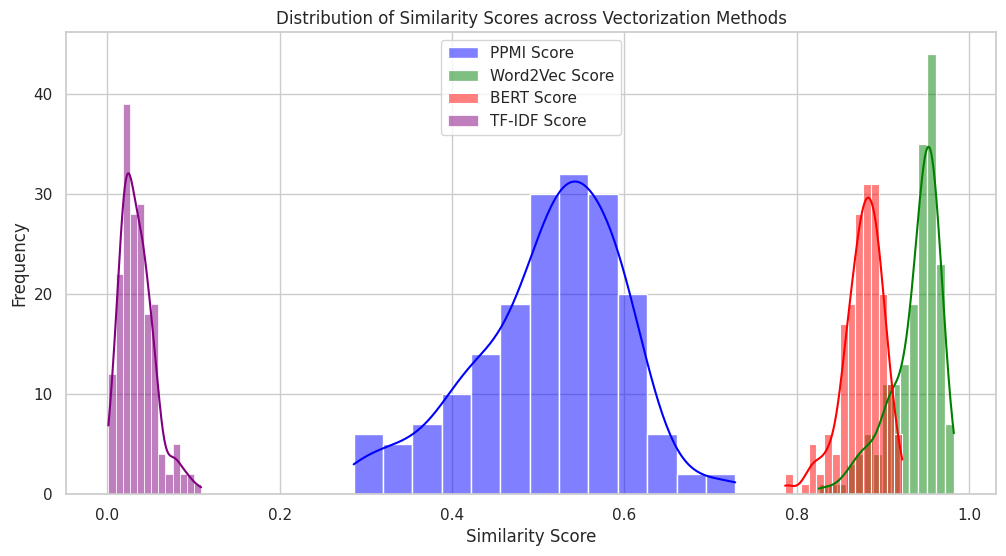

In [ ]:
# Step 3: Visualization of distributions
plt.figure(figsize=(12, 6))
sns.histplot(df['ppmi_score'], kde=True, label="PPMI Score", color="blue", alpha=0.5)
sns.histplot(df['word2vec_score'], kde=True, label="Word2Vec Score", color="green", alpha=0.5)
sns.histplot(df['bert_score'], kde=True, label="BERT Score", color="red", alpha=0.5)
sns.histplot(df['tfidf_score'], kde=True, label="TF-IDF Score", color="purple", alpha=0.5)
plt.legend()
plt.title("Distribution of Similarity Scores across Vectorization Methods")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

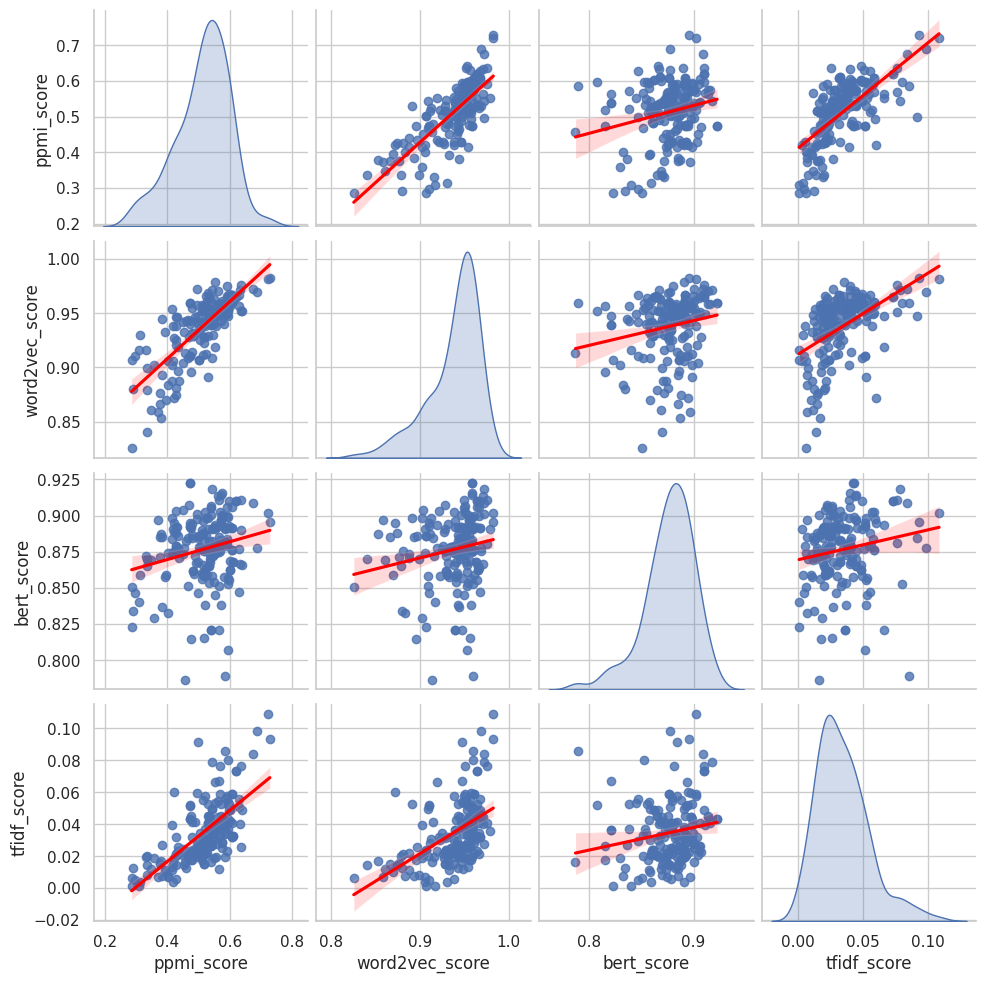

In [ ]:
# Step 4: Scatter Matrix for Relationship Analysis
sns.pairplot(df[['ppmi_score', 'word2vec_score', 'bert_score', 'tfidf_score']], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.show()

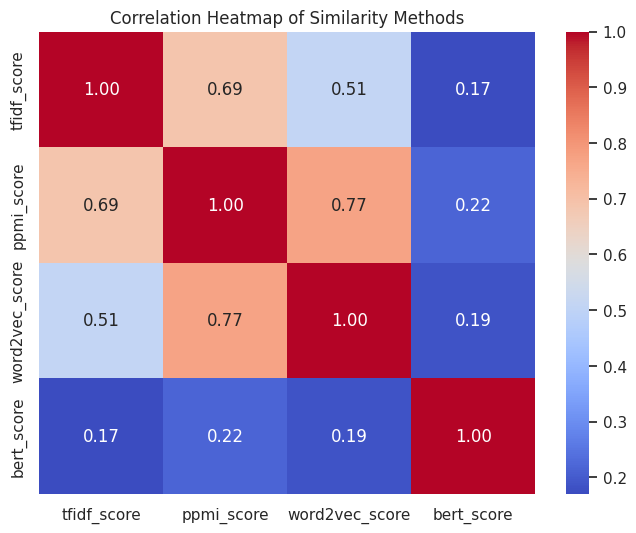

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["tfidf_score", "ppmi_score", "word2vec_score", "bert_score"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Similarity Methods")
plt.show()

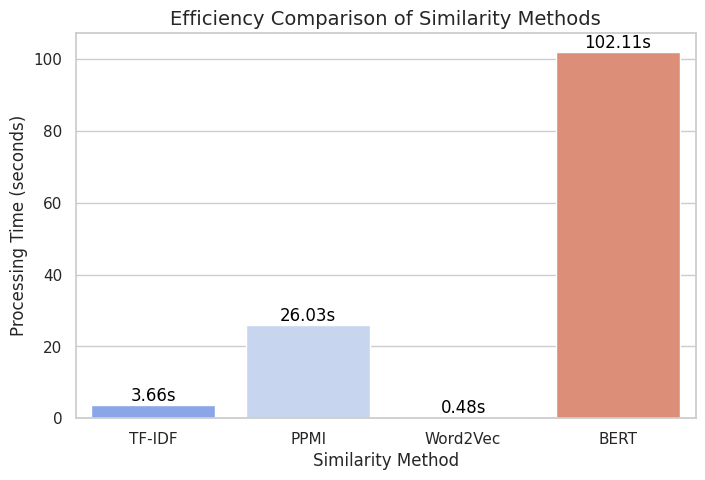

In [ ]:
# Create a duration dictionary
durations = {
    "Method": ["TF-IDF", "PPMI", "Word2Vec", "BERT"],
    "Time (seconds)": [tfidf_duration, ppmi_duration, word2vec_duration, bert_duration]
}

# Convert to DataFrame
df_durations = pd.DataFrame(durations)

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Create Bar Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Method", y="Time (seconds)", hue="Method", data=df_durations, palette="coolwarm", legend=False)

# Add data labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color="black")

# Titles and labels
plt.title("Efficiency Comparison of Similarity Methods", fontsize=14)
plt.xlabel("Similarity Method", fontsize=12)
plt.ylabel("Processing Time (seconds)", fontsize=12)

# Show the plot
plt.show()

<ipython-input-161-f3bf704e38ca>:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
<ipython-input-161-f3bf704e38ca>:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
<ipython-input-161-f3bf704e38ca>:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
<ipython-input-161-f3bf704e38ca>:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


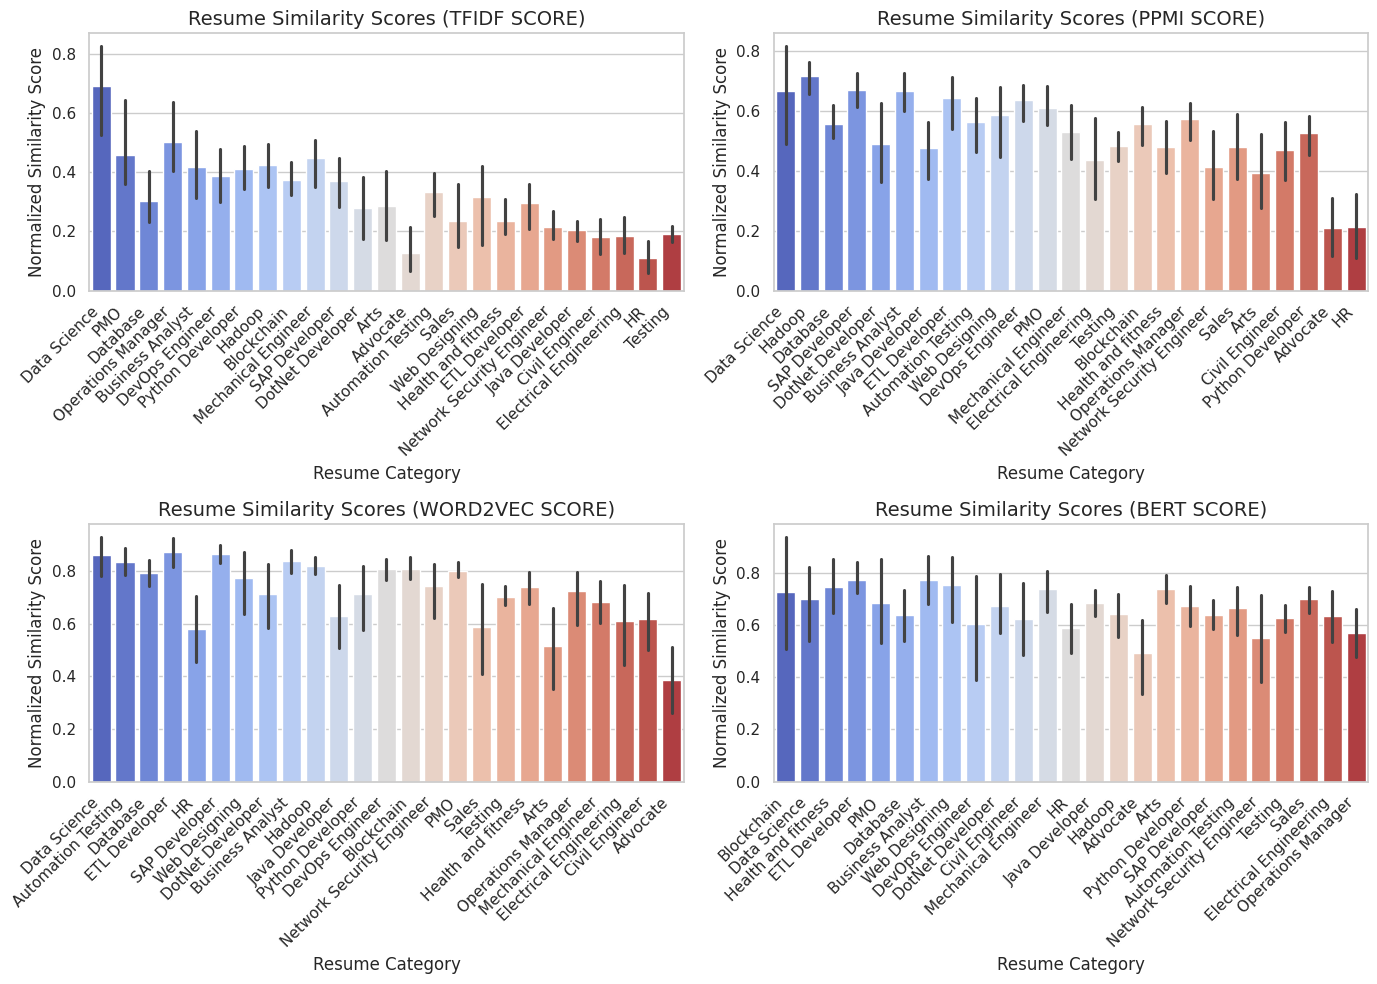

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select similarity score columns
score_columns = ["tfidf_score", "ppmi_score", "word2vec_score", "bert_score"]

# Apply Min-Max Normalization (0 to 1)
scaler = MinMaxScaler()
df[score_columns] = scaler.fit_transform(df[score_columns])

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Create separate plots for each method
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 grid of plots

for i, (ax, method) in enumerate(zip(axes.flatten(), score_columns)):
    # Sort the dataframe by the current method's scores in descending order
    df_sorted = df.sort_values(by=method, ascending=False)

    # Plot each similarity score separately
    sns.barplot(x=df_sorted["category"], y=df_sorted[method], hue=df_sorted["category"], ax=ax, palette="coolwarm")

    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Set titles and labels
    ax.set_title(f"Resume Similarity Scores ({method.replace('_', ' ').upper()})", fontsize=14)
    ax.set_xlabel("Resume Category", fontsize=12)
    ax.set_ylabel("Normalized Similarity Score", fontsize=12)

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

In [ ]:
# Define the similarity score columns
score_columns = ["tfidf_score", "ppmi_score", "word2vec_score", "bert_score"]

# Create a dictionary to store the top 10 results for each method
top_10_dict = {}

for method in score_columns:
    # Sort DataFrame by similarity score in descending order
    df_sorted = df.sort_values(by=method, ascending=False).head(10)

    # Store the top 10 results for this method
    top_10_dict[method] = df_sorted[["category", method]]  # Keep only category and score

# Merge all results into a single DataFrame
df_top_10 = pd.concat(top_10_dict, axis=1)

# Rename columns for better readability
df_top_10.columns = ["TF-IDF Job Role", "TF-IDF Score",
                      "PPMI Job Role", "PPMI Score",
                      "Word2Vec Job Role", "Word2Vec Score",
                      "BERT Job Role", "BERT Score"]

# Reset index
df_top_10.reset_index(drop=True, inplace=True)

# Define the similarity score columns (only job roles)
role_columns = ["TF-IDF Job Role", "PPMI Job Role", "Word2Vec Job Role", "BERT Job Role"]

# Collect top 10 unique job roles from all methods (drop NaNs and keep unique)
top_10_roles = pd.DataFrame()

for method in role_columns:
    method_roles = df_top_10[method].dropna().tolist()  # Remove NaNs and get unique roles
    top_10_roles[method] = pd.Series(method_roles[:10])  # Ensure only 10 per method

top_10_roles

,TF-IDF Job Role,PPMI Job Role,Word2Vec Job Role,BERT Job Role
0,Data Science,Data Science,Data Science,Data Science
1,Data Science,Data Science,Data Science,Database
2,Data Science,Data Science,Data Science,ETL Developer
3,Data Science,Data Science,Data Science,Blockchain
4,Data Science,Database,Database,Blockchain
5,Data Science,Hadoop,SAP Developer,Blockchain
6,PMO,Hadoop,Automation Testing,Health and fitness
7,Data Science,SAP Developer,ETL Developer,PMO
8,Database,Hadoop,HR,Business Analyst
9,Operations Manager,DotNet Developer,ETL Developer,Business Analyst


Most suitable vectorizations in order:
1. TF-IDF
2. Word2Vec
3. BERT
4. PPMI

#### Export

In [ ]:
# Rename tokens_cleaned to resume and join into a string
df["resume"] = df["tokens_cleaned"].apply(lambda x: " ".join(x))

# Drop tokens_cleaned
df.drop(["tokens_cleaned"], axis=1, inplace=True)

df.head()

,category,tfidf_score,ppmi_score,word2vec_score,bert_score,resume
0,Hadoop,0.535638,0.726350,0.859249,0.657253,technical skill set program language APACHE HA...
1,Mechanical Engineer,0.524073,0.527304,0.717994,0.850779,SKILLS knowledge software computer AUTO CAD in...
2,Testing,0.129633,0.520317,0.651945,0.651840,skill set OS WINDOWS XP 7 8 8 1 10 DATABASE MY...
3,Electrical Engineering,0.176215,0.410151,0.529001,0.474261,education detail january 2012 january 2013 b e...
4,Business Analyst,0.366628,0.724253,0.894604,0.876481,key skill REQUIREMENT GATHERING REQUIREMENT an...


In [ ]:
# export
df.to_csv("similarity_final.csv")

# BERT Preparation

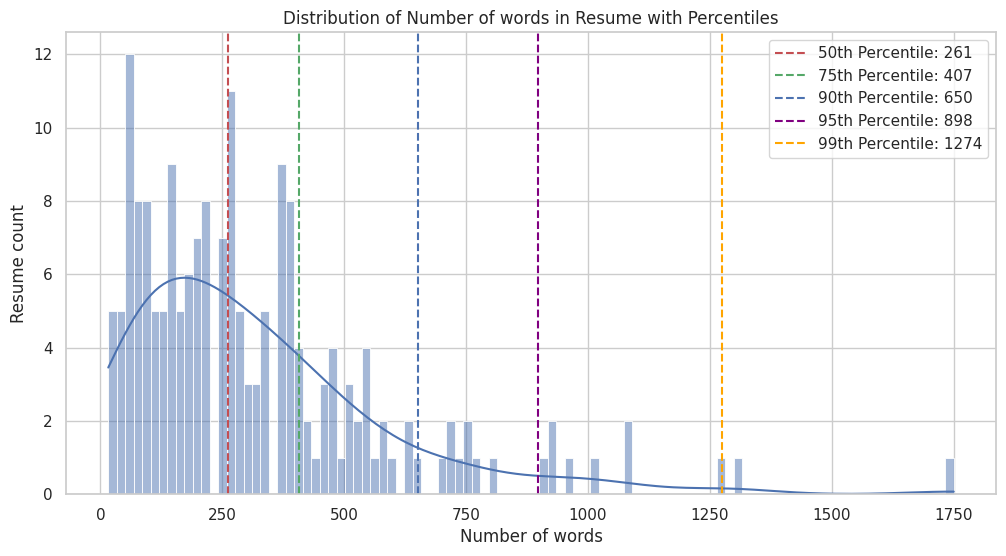

In [ ]:
plot_distribution(df, 'resume')

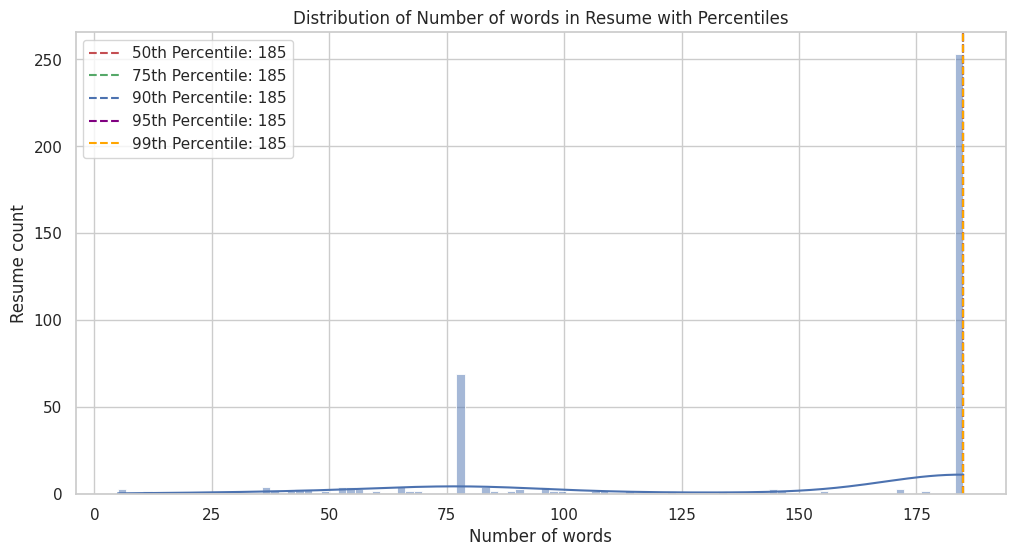

In [ ]:
# still, the resumes are too long for BERT's max token length
# split them into multiple rows with fewer words

# Define max words per row and overlap size
MAX_WORDS = 185 # 192 words for 256 tokens
OVERLAP = 20  # Overlap 20 words from the previous chunk

# Function to split resume text with overlap
def split_resume(row):
    words = row["resume"].split()  # Tokenize by whitespace
    if len(words) <= MAX_WORDS:
        return [row]  # Keep as is if under the limit

    # Create overlapping chunks
    chunks = [words[i:i + MAX_WORDS] for i in range(0, len(words), MAX_WORDS - OVERLAP)]

    # Create new rows for each chunk
    new_rows = [{"category": row["category"], "resume": " ".join(chunk)} for chunk in chunks]
    return new_rows

# Apply function to all rows and expand into a new DataFrame
df_split = pd.DataFrame([row for rows in df.apply(split_resume, axis=1) for row in rows])

# Reset index for clean formatting
df_split.reset_index(drop=True, inplace=True)

plot_distribution(df_split, 'resume')

In [ ]:
# export
df_split[['category', 'resume']].to_csv("BERT_data_final.csv")